<a href="https://colab.research.google.com/github/sysuevvvw-bot/titanic/blob/main/treeeee.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn import tree
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification


In [2]:
train = pd.read_csv("train.csv")
test =  pd.read_csv("test.csv")
gender_submission =  pd.read_csv("gender_submission.csv")

In [3]:
X = train.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'Survived'], axis = 1)
X = pd.get_dummies(X)
X = X.fillna({'Age': X.Age.median()})
y = train.Survived

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42, stratify = y)

In [17]:
parameters = {'n_estimators': 19, 'criterion' : ['gini', 'entropy'], 'max_depth' : range(1,7)}

In [7]:
clf_rf = RandomForestClassifier()

In [8]:
grid_search_cv_clf = GridSearchCV(clf_rf, parameters, cv = 5)

In [10]:
grid_search_cv_clf.fit(X_train, y_train)
best_clf = grid_search_cv_clf.best_estimator_
y_predicted_prob = best_clf.predict_proba(X_test)

In [12]:
y_pred = best_clf.predict(X_test)

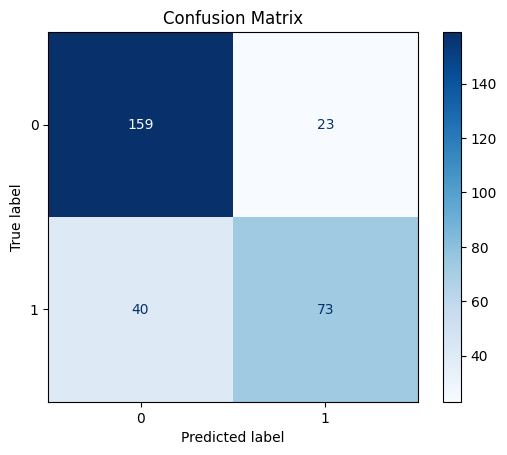

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [14]:
precision_score(y_test, y_pred)

0.7604166666666666

In [15]:
recall_score(y_test, y_pred)

0.6460176991150443

In [16]:
grid_search_cv_clf.best_estimator_

RandomForestClassifier(max_depth=6, n_estimators=19)

In [18]:
best_clf.score(X_test, y_test)

0.7864406779661017

In [22]:
feature_importances = best_clf.feature_importances_

In [24]:
feature_importances_df = pd.DataFrame({'feature': list(X_train),
                                       'feature_importances': feature_importances})

In [25]:
feature_importances_df

,feature,feature_importances
0,Pclass,0.112696
1,Age,0.156410
2,SibSp,0.040752
3,Parch,0.038882
4,Fare,0.161675
5,Sex_female,0.179646
6,Sex_male,0.281616
7,Embarked_C,0.011685
8,Embarked_Q,0.007210
9,Embarked_S,0.009427


In [ ]:
# parameters = {'criterion' : ['gini', 'entropy'], 'max_depth' : range(1,30)}
# clf = tree.DecisionTreeClassifier()
# grid_search_cv_clf = GridSearchCV(clf, parameters, cv = 5)

In [ ]:
# grid_search_cv_clf.fit(X_train, y_train)
# best_clf = grid_search_cv_clf.best_estimator_
# y_predicted_prob = best_clf.predict_proba(X_test)

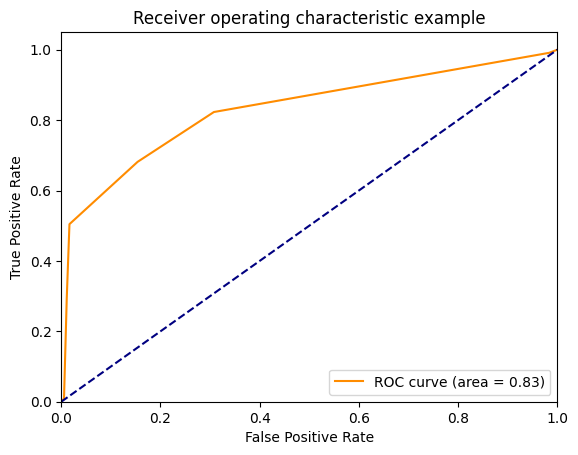

In [ ]:
# from sklearn.metrics import roc_curve, auc
# import matplotlib.pyplot as plt

# # Предположим, что y_test и y_predicted_prob уже определены
# fpr, tpr, thresholds = roc_curve(y_test, y_predicted_prob[:, 1])
# roc_auc = auc(fpr, tpr)

# # Создание нового графического окна
# plt.figure()

# # Построение ROC-кривой
# plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver operating characteristic example')
# plt.legend(loc="lower right")

# # Отображение графика
# plt.show()